In [ ]:
!pip install torch-geometric -q

import os
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing, global_mean_pool, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer
import warnings

warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Ορισμός Διαδρομών
MODEL_PATH = '/content/drive/MyDrive/team3_xai_gnn/nnconv_results/outer_checkpoints/cfg00_outer1.pt'
TEST_PATH  = '/content/drive/MyDrive/team3_xai_gnn/preprocessed/fold_1_test.pt'
DMRI_PATH  = '/content/drive/MyDrive/team3_xai_gnn/oasis3_graphmls_scale1'

NODE_FEATURE_NAMES = ['volume', 'thickness', 'has_volume', 'has_thickness']
CLASS_NAMES        = {0: 'CN', 1: 'MCI'}

Mounted at /content/drive
Using device: cuda


In [3]:
# Η κλάση κληρονομεί από το MessagePassing με aggr='add'
class NNConvLayer(MessagePassing):
    def __init__(self, in_channels, edge_dim, out_channels):
        super(NNConvLayer, self).__init__(aggr='add')
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, in_channels * out_channels)
        )
        # ΑΛΛΑΓΗ: Μετονομασία σε in_channels και out_channels για να μη συγκρούεται με το PyG
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.gru = nn.GRUCell(out_channels, in_channels)

    def forward(self, x, edge_index, edge_attr):
        # Υπολογισμός του πίνακα βαρών W από τα χαρακτηριστικά των ακμών (DTI)
        W = self.edge_mlp(edge_attr).view(-1, self.in_channels, self.out_channels)

        # Η propagate αναλαμβάνει την κατανομή των μηνυμάτων
        agg = self.propagate(edge_index, x=x, W=W)
        return self.gru(agg, x)

    def message(self, x_j, W):
        # x_j: Χαρακτηριστικά των κόμβων-πηγών (num_edges, in_channels)
        # W: Πίνακες βαρών των ακμών (num_edges, in_channels, out_channels)
        msg = torch.bmm(x_j.unsqueeze(1), W).squeeze(1)
        return msg

class NNConvNet(nn.Module):
    def __init__(self, node_in, edge_in, hidden, dropout):
        super().__init__()
        self.input_proj = nn.Linear(node_in, hidden)
        self.input_norm = nn.BatchNorm1d(hidden)
        self.conv1 = NNConvLayer(hidden, edge_in, hidden)
        self.norm1 = nn.BatchNorm1d(hidden)
        self.conv2 = NNConvLayer(hidden, edge_in, hidden)
        self.norm2 = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.input_proj(x)
        x = self.input_norm(x).relu()
        x = self.dropout(self.norm1(self.conv1(x, edge_index, edge_attr)).relu())
        x = self.dropout(self.norm2(self.conv2(x, edge_index, edge_attr)).relu())
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        return self.classifier(x)


In [4]:
# Φόρτωση Μοντέλου
model = NNConvNet(node_in=4, edge_in=15, hidden=32, dropout=0.3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print('Το μοντέλο φορτώθηκε.')

# Φόρτωση Γράφων (Ασθενείς)
test_graphs = torch.load(TEST_PATH, map_location=device, weights_only=False)
print(f'Συνολικοί ασθενείς (test graphs): {len(test_graphs)}')

# Ανάκτηση των ονομάτων των περιοχών του εγκεφάλου από τα GraphML αρχεία
graphml_files = sorted([f for f in os.listdir(DMRI_PATH) if f.endswith('.graphml')])
sample_G      = nx.read_graphml(os.path.join(DMRI_PATH, graphml_files[0]))
sample_G.remove_edges_from(list(nx.selfloop_edges(sample_G)))
nodes       = list(sample_G.nodes(data=True))
node_labels = {i: attrs.get('dn_name', f'node_{i}').strip() for i, (_, attrs) in enumerate(nodes)}
print(f'Ολοκληρώθηκε η αντιστοίχιση για {len(node_labels)} ανατομικές περιοχές (ROIs)')

Το μοντέλο φορτώθηκε.
Συνολικοί ασθενείς (test graphs): 127
Ολοκληρώθηκε η αντιστοίχιση για 124 ανατομικές περιοχές (ROIs)


In [5]:
# 1. Ορισμός του GNNExplainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw',
    ),
)

# Συνάρτηση για οπτικοποίηση με τα πραγματικά ονόματα των κόμβων (ROIs)
def visualize_gnnexplainer(explanation, data, node_labels, top_k=10):
    edge_mask = explanation.edge_mask.cpu().numpy()
    top_indices = np.argsort(edge_mask)[-top_k:]

    G = nx.Graph()
    edge_index = data.edge_index.cpu().numpy()

    for idx in top_indices:
        u, v = edge_index[0, idx], edge_index[1, idx]
        u_label = node_labels.get(u, f"Node {u}")
        v_label = node_labels.get(v, f"Node {v}")
        G.add_edge(u_label, v_label, weight=edge_mask[idx])

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=1.5, seed=42)

    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='#FF7F50', edgecolors='black')
    weights = [G[u][v]['weight'] * 10 for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title(f"GNNExplainer: Top {top_k} Κρίσιμες Νευρικές Οδοί (NNConv Model)", pad=20, fontsize=14)
    plt.axis('off')
    plt.show()

print('Ο Explainer αρχικοποιήθηκε επιτυχώς!')

Ο Explainer αρχικοποιήθηκε επιτυχώς!


=== ΑΝΑΛΥΣΗ ΑΣΘΕΝΗ: OAS30037 ===
Πραγματική Διάγνωση : CN
Πρόβλεψη Μοντέλου   : CN (Σιγουριά: 68.9%)

 ΑΠΟΤΕΛΕΣΜΑΤΑ GNNEXPLAINER (Top Λίστες)

[1] ΣΗΜΑΝΤΙΚΟΤΗΤΑ ΒΙΟΛΟΓΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ:
  - volume          : 0.113114
  - thickness       : 0.085639
  - has_volume      : 0.107752
  - has_thickness   : 0.141260

[2] TOP 10 ΠΙΟ ΣΗΜΑΝΤΙΚΕΣ ΠΕΡΙΟΧΕΣ ΕΓΚΕΦΑΛΟΥ (ROIs):
  01. Right-Accumbens_area                | Score: 0.697107
  02. ctx-lh-lingual                      | Score: 0.304386
  03. ctx-lh-middletemporal               | Score: 0.264845
  04. Right-Pulvinar                      | Score: 0.257617
  05. ctx-lh-parsopercularis              | Score: 0.252004
  06. ctx-lh-precuneus                    | Score: 0.245789
  07. ctx-rh-superiorfrontal              | Score: 0.245421
  08. Left-Caudate                        | Score: 0.232156
  09. ctx-rh-parsorbitalis                | Score: 0.223137
  10. Brain_Stem-Medulla                  | Score: 0.209772

[3] TOP 10 ΠΙΟ ΣΗΜΑΝΤΙΚΕΣ ΣΥΝΔΕΣ

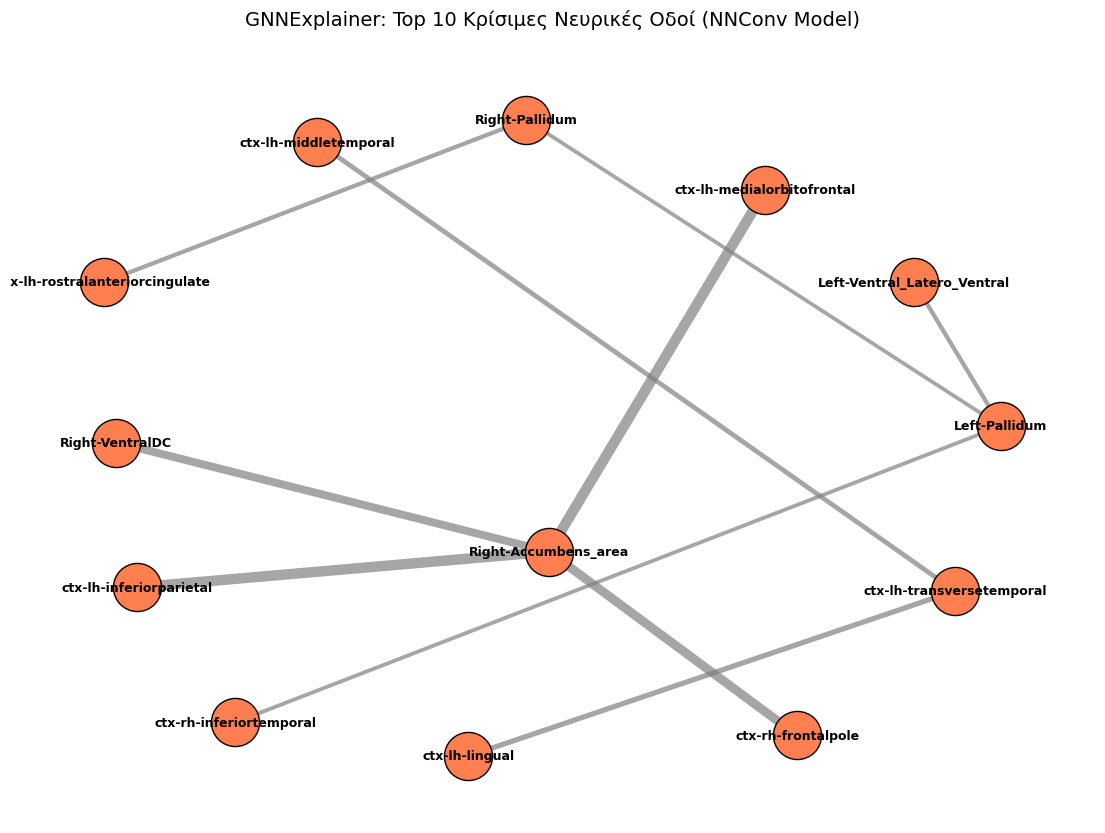

In [6]:
# 1. Εύρεση του ασθενή και της πρόβλεψης
patient_idx = 5
g = test_graphs[patient_idx].to(device)
batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)

with torch.no_grad():
    logits = model(g.x, g.edge_index, g.edge_attr, batch)
    probs = torch.softmax(logits, dim=-1)
    pred_class = logits.argmax(dim=-1).item()
    confidence = probs[0, pred_class].item()

    print(f"=== ΑΝΑΛΥΣΗ ΑΣΘΕΝΗ: {g.subject_id} ===")
    print(f"Πραγματική Διάγνωση : {CLASS_NAMES[g.y.item()]}")
    print(f"Πρόβλεψη Μοντέλου   : {CLASS_NAMES[pred_class]} (Σιγουριά: {confidence*100:.1f}%)")


# 2. Εκτέλεση του GNNExplainer
explanation = explainer(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, batch=batch)

print("\n" + "="*50)
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ GNNEXPLAINER (Top Λίστες)")
print("="*50)

feat_imp = explanation.node_mask.cpu().numpy().mean(axis=0)
print('\n[1] ΣΗΜΑΝΤΙΚΟΤΗΤΑ ΒΙΟΛΟΓΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ:')
for name, imp in zip(NODE_FEATURE_NAMES, feat_imp):
    print(f"  - {name:<15s} : {imp:.6f}")

node_imp = explanation.node_mask.cpu().numpy().mean(axis=1)
top_node_indices = np.argsort(node_imp)[::-1][:10]
print('\n[2] TOP 10 ΠΙΟ ΣΗΜΑΝΤΙΚΕΣ ΠΕΡΙΟΧΕΣ ΕΓΚΕΦΑΛΟΥ (ROIs):')
for rank, idx in enumerate(top_node_indices):
    node_name = node_labels.get(idx, f"Node {idx}")
    print(f"  {rank+1:02d}. {node_name:<35s} | Score: {node_imp[idx]:.6f}")


edge_mask = explanation.edge_mask.cpu().numpy()
top_edge_indices = np.argsort(edge_mask)[::-1][:10]
edge_index = g.edge_index.cpu().numpy()
print('\n[3] TOP 10 ΠΙΟ ΣΗΜΑΝΤΙΚΕΣ ΣΥΝΔΕΣΕΙΣ ΛΕΥΚΗΣ ΟΥΣΙΑΣ (Tracts):')
for rank, idx in enumerate(top_edge_indices):
    u, v = edge_index[0, idx], edge_index[1, idx]
    u_label = node_labels.get(u, f"Node {u}")
    v_label = node_labels.get(v, f"Node {v}")
    print(f"  {rank+1:02d}. {u_label[:20]:<20s} <--> {v_label[:20]:<20s} | Score: {edge_mask[idx]:.6f}")


# 3. Οπτικοποίηση Δομικής Συνδεσιμότητας
print('\n[4] ΔΗΜΙΟΥΡΓΙΑ ΓΡΑΦΗΜΑΤΟΣ (ΟΠΤΙΚΟΠΟΙΗΣΗ ΥΠΟΓΡΑΦΗΜΑΤΟΣ)...')
visualize_gnnexplainer(explanation, g, node_labels, top_k=10)

In [7]:
def get_prediction(g):
    g = g.to(device)
    batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(g.x, g.edge_index, g.edge_attr, batch)
        probs  = torch.softmax(logits, dim=-1)
        pred   = logits.argmax(dim=-1).item()
    return pred, probs[0, 0].item(), probs[0, 1].item()


results = []
for g in test_graphs:
    pred, prob_cn, prob_mci = get_prediction(g)
    results.append((g, g.y.item(), pred, prob_mci))

TP = sorted([(g, t, p, s) for g, t, p, s in results if t == 1 and p == 1], key=lambda x: -x[3])
TN = sorted([(g, t, p, s) for g, t, p, s in results if t == 0 and p == 0], key=lambda x:  x[3])
FP = sorted([(g, t, p, s) for g, t, p, s in results if t == 0 and p == 1], key=lambda x: -x[3])
FN = sorted([(g, t, p, s) for g, t, p, s in results if t == 1 and p == 0], key=lambda x:  x[3])

mci_pool = [(g, t, p, s) for g, t, p, s in results if t == 1]
cn_pool  = [(g, t, p, s) for g, t, p, s in results if t == 0]

print(f'TP: {len(TP)}  TN: {len(TN)}  FP: {len(FP)}  FN: {len(FN)}')
print(f'True MCI: {len(mci_pool)}  |  True CN: {len(cn_pool)}')
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if pool:
        g, t, p, s = pool[0]
        print(f'  Most confident {tag}: {g.subject_id}  P(MCI)={s:.4f}')

TP: 14  TN: 87  FP: 18  FN: 8
True MCI: 22  |  True CN: 105
  Most confident TP: OAS31004  P(MCI)=0.6972
  Most confident TN: OAS30723  P(MCI)=0.2792
  Most confident FP: OAS30443  P(MCI)=0.7888
  Most confident FN: OAS31050  P(MCI)=0.3662


In [8]:
def run_gnnexplainer(subject, target=None, explanation_type='model'):
    '''
    Runs GNNExplainer for a single subject.

    target           : required when explanation_type='phenomenon'
                       (the class label the explanation is anchored to: 0=CN, 1=MCI)
    explanation_type : 'model'      -> explain whatever class the model predicts
                       'phenomenon' -> explain a specific target class

    Returns:
        node_imp : (num_nodes,)            mean of node_mask across feature dims
        feat_imp : (num_features,)         mean of node_mask across nodes
        edge_imp : (num_edges,)            edge mask
        node_full: (num_nodes, num_feats)  raw node_mask
    '''
    subject = subject.to(device)
    batch   = torch.zeros(subject.x.size(0), dtype=torch.long, device=device)

    # build a fresh explainer matching the requested explanation_type
    expl = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type=explanation_type,
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='multiclass_classification',
            task_level='graph',
            return_type='raw',
        ),
    )

    kwargs = dict(x=subject.x, edge_index=subject.edge_index,
                  edge_attr=subject.edge_attr, batch=batch)
    if explanation_type == 'phenomenon':
        kwargs['target'] = torch.tensor([target], device=device)

    explanation = expl(**kwargs)

    node_mask = explanation.node_mask.detach().cpu().numpy()    # (N, F)
    edge_mask = explanation.edge_mask.detach().cpu().numpy()    # (E,)

    node_imp = node_mask.mean(axis=1)
    feat_imp = node_mask.mean(axis=0)

    return node_imp, feat_imp, edge_mask, node_mask


print('GNNExplainer wrapper ready.')

GNNExplainer wrapper ready.



----------------------------------------------------------------------------------------------------
TP | OAS31004 | True: MCI - Pred: MCI
  Feature importance:
    volume          | 0.119578
    thickness       | 0.086064
    has_volume      | 0.111748
    has_thickness   | 0.092806
  Top 10 ROIs:
    Rank 01 | Brain_Stem-Midbrain                           | 0.779449
    Rank 02 | ctx-lh-caudalanteriorcingulate                | 0.396335
    Rank 03 | Right-Pulvinar                                | 0.268704
    Rank 04 | ctx-lh-isthmuscingulate                       | 0.261496
    Rank 05 | ctx-rh-entorhinal                             | 0.256198
    Rank 06 | ctx-lh-inferiortemporal                       | 0.249730
    Rank 07 | ctx-rh-supramarginal                          | 0.204915
    Rank 08 | Left-Pulvinar                                 | 0.189669
    Rank 09 | ctx-rh-precentral                             | 0.178392
    Rank 10 | ctx-lh-frontalpole                            

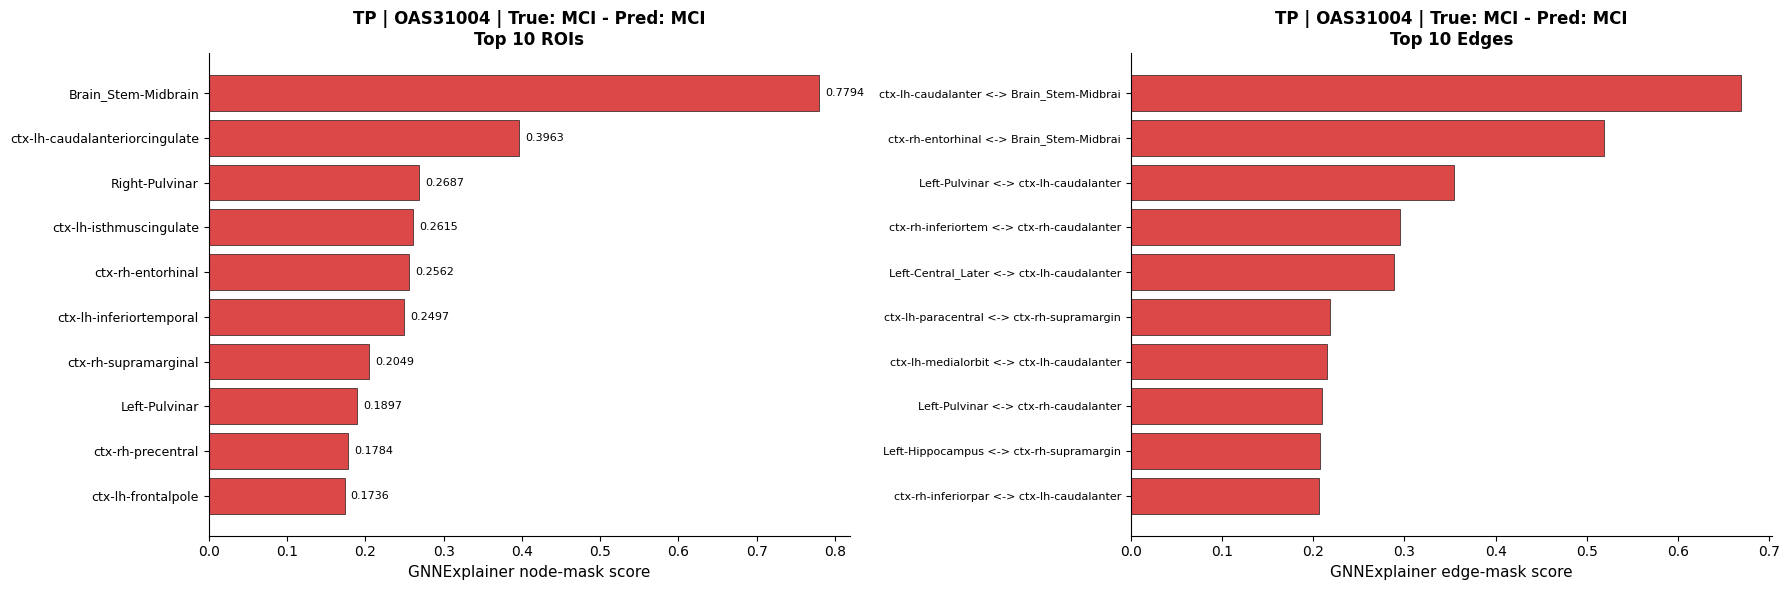


----------------------------------------------------------------------------------------------------
TN | OAS30723 | True: CN - Pred: CN
  Feature importance:
    volume          | 0.247584
    thickness       | 0.168038
    has_volume      | 0.195724
    has_thickness   | 0.129057
  Top 10 ROIs:
    Rank 01 | ctx-rh-parahippocampal                        | 0.528405
    Rank 02 | ctx-lh-cuneus                                 | 0.463928
    Rank 03 | ctx-lh-lingual                                | 0.402188
    Rank 04 | Right-Pallidum                                | 0.399359
    Rank 05 | ctx-rh-inferiortemporal                       | 0.398280
    Rank 06 | ctx-lh-pericalcarine                          | 0.391599
    Rank 07 | ctx-lh-lateralorbitofrontal                   | 0.389351
    Rank 08 | Right-Ventral_Latero_Dorsal                   | 0.376096
    Rank 09 | ctx-rh-temporalpole                           | 0.375228
    Rank 10 | ctx-lh-inferiortemporal                       | 

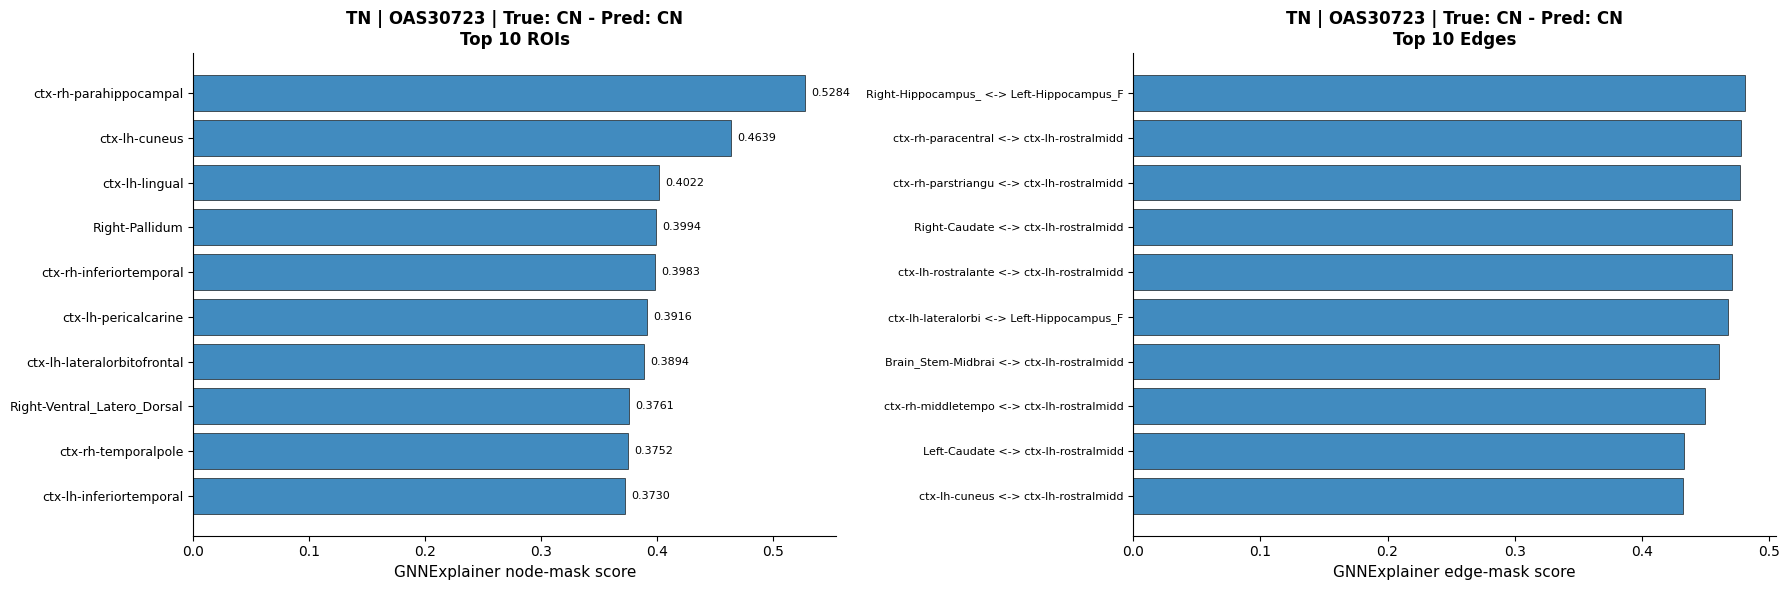


----------------------------------------------------------------------------------------------------
FP | OAS30443 | True: CN - Pred: MCI
  Feature importance:
    volume          | 0.136181
    thickness       | 0.081638
    has_volume      | 0.115611
    has_thickness   | 0.087569
  Top 10 ROIs:
    Rank 01 | Right-Pulvinar                                | 0.680410
    Rank 02 | ctx-rh-precentral                             | 0.478687
    Rank 03 | ctx-rh-parsorbitalis                          | 0.363239
    Rank 04 | Right-Amygdala                                | 0.354203
    Rank 05 | ctx-rh-precuneus                              | 0.324721
    Rank 06 | ctx-rh-fusiform                               | 0.299700
    Rank 07 | ctx-lh-pericalcarine                          | 0.298171
    Rank 08 | ctx-lh-rostralmiddlefrontal                   | 0.254617
    Rank 09 | ctx-lh-transversetemporal                     | 0.230855
    Rank 10 | Right-VentralDC                               |

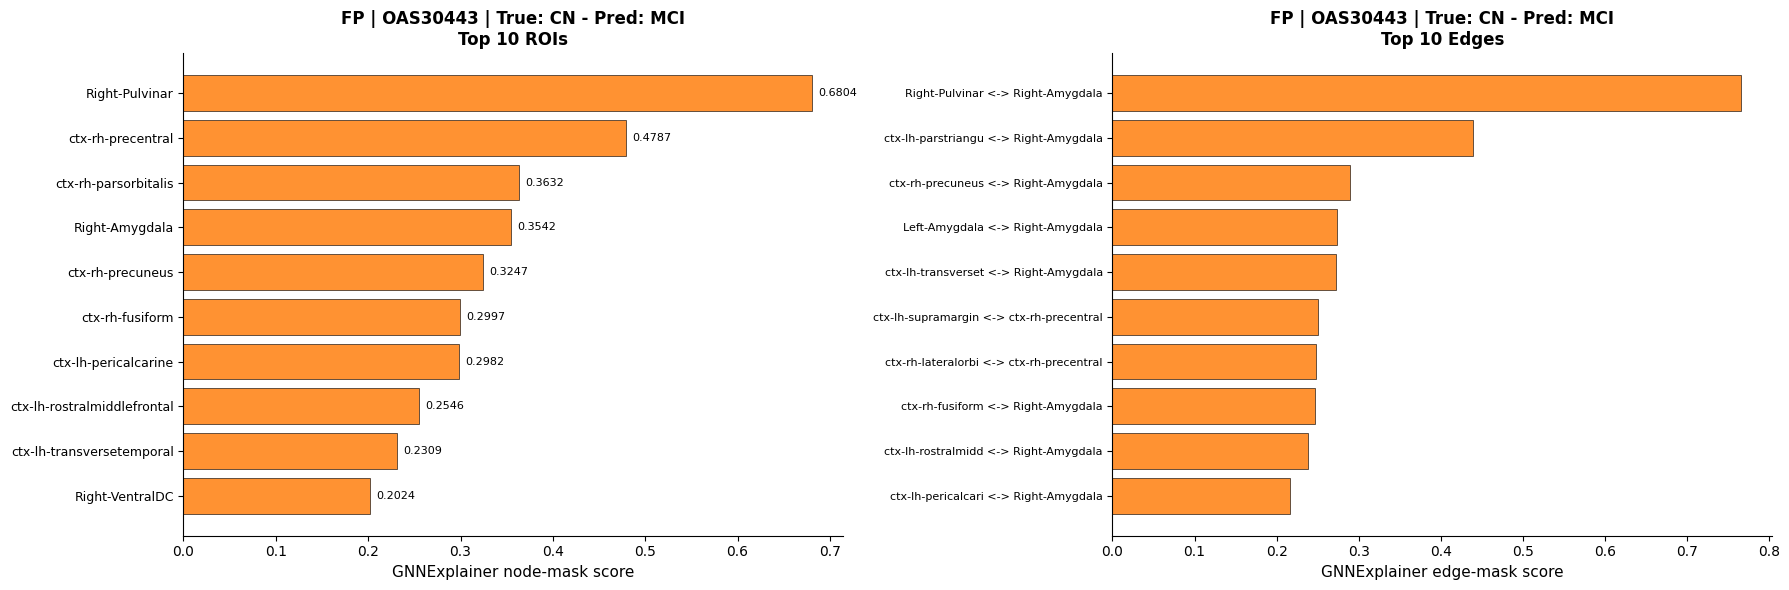


----------------------------------------------------------------------------------------------------
FN | OAS31050 | True: MCI - Pred: CN
  Feature importance:
    volume          | 0.100186
    thickness       | 0.090607
    has_volume      | 0.116895
    has_thickness   | 0.137015
  Top 10 ROIs:
    Rank 01 | ctx-rh-inferiortemporal                       | 0.269967
    Rank 02 | ctx-rh-temporalpole                           | 0.267748
    Rank 03 | ctx-rh-rostralanteriorcingulate               | 0.254463
    Rank 04 | ctx-lh-isthmuscingulate                       | 0.240798
    Rank 05 | ctx-lh-parsorbitalis                          | 0.240450
    Rank 06 | ctx-rh-caudalmiddlefrontal                    | 0.238773
    Rank 07 | Right-Ventral_Anterior                        | 0.237054
    Rank 08 | Left-Ventral_Anterior                         | 0.236754
    Rank 09 | Brain_Stem-Medulla                            | 0.234225
    Rank 10 | Brain_Stem-SCP                                |

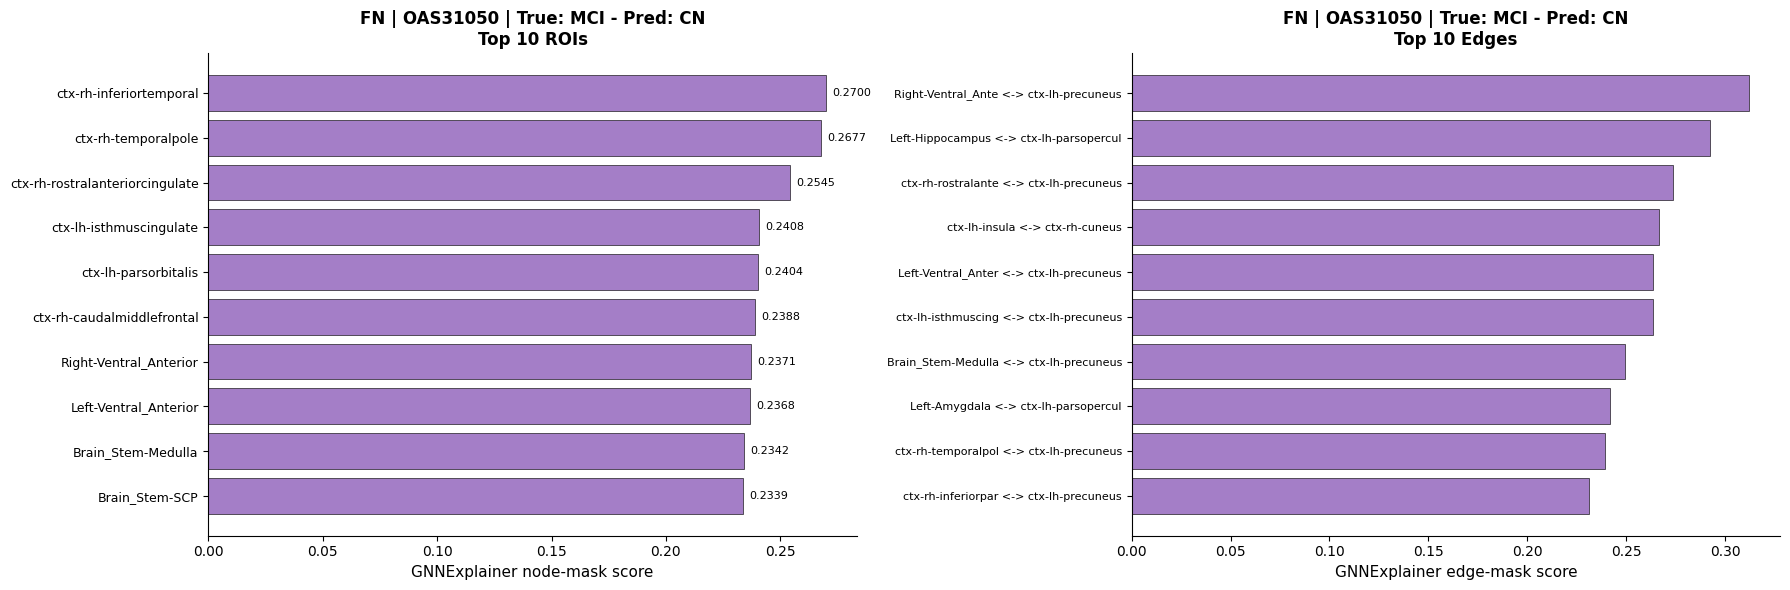

In [9]:
def get_top_nodes(node_importance, node_labels, top_n=10):
    top_idx    = np.argsort(node_importance)[::-1][:top_n]
    top_names  = [node_labels[i] for i in top_idx]
    top_scores = node_importance[top_idx]
    return top_idx, top_names, top_scores


def plot_top_nodes(ax, names, scores, title, color):
    names  = list(names[::-1])
    scores = list(scores[::-1])
    bars   = ax.barh(names, scores, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('GNNExplainer node-mask score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + max(scores) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)


def plot_top_edges(ax, edge_imp, edge_index, node_labels, title, color, top_n=10):
    top_idx = np.argsort(edge_imp)[::-1][:top_n]
    names, scores = [], []
    for idx in top_idx:
        u, v = edge_index[0, idx], edge_index[1, idx]
        names.append(f'{node_labels.get(int(u), str(u))[:18]} <-> {node_labels.get(int(v), str(v))[:18]}')
        scores.append(edge_imp[idx])
    names, scores = names[::-1], scores[::-1]
    ax.barh(names, scores, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('GNNExplainer edge-mask score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)


# ------------------ per-outcome on the most-confident subjects ------------------
outcome_colors = {'TP': '#d62728', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#9467bd'}
outcome_cases  = {}

for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if not pool:
        print(f'{tag}: empty, skipping.')
        continue
    g, true, pred, _ = pool[0]
    node_imp, feat_imp, edge_imp, _ = run_gnnexplainer(g, explanation_type='model')
    outcome_cases[tag] = dict(g=g, true=true, pred=pred,
                              node_imp=node_imp, feat_imp=feat_imp, edge_imp=edge_imp)

    _, top_names, top_scores = get_top_nodes(node_imp, node_labels)
    title = (f'{tag} | {g.subject_id} | True: {CLASS_NAMES[true]} - Pred: {CLASS_NAMES[pred]}')

    print(f'\n{"-"*100}\n{title}')
    print('  Feature importance:')
    for nm, imp in zip(NODE_FEATURE_NAMES, feat_imp):
        print(f'    {nm:<15s} | {imp:.6f}')
    print('  Top 10 ROIs:')
    for r, (n, s) in enumerate(zip(top_names, top_scores)):
        print(f'    Rank {r+1:02d} | {n:<45s} | {s:.6f}')

    c = outcome_colors[tag]
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plot_top_nodes(axes[0], top_names, top_scores,
                   f'{title}\nTop 10 ROIs', c)
    plot_top_edges(axes[1], edge_imp, g.edge_index.cpu().numpy(), node_labels,
                   f'{title}\nTop 10 Edges', c)
    plt.tight_layout()
    plt.show()

TP (n=14): population GNNExplainer done.
TN (n=87): population GNNExplainer done.
FP (n=18): population GNNExplainer done.
FN (n=8): population GNNExplainer done.


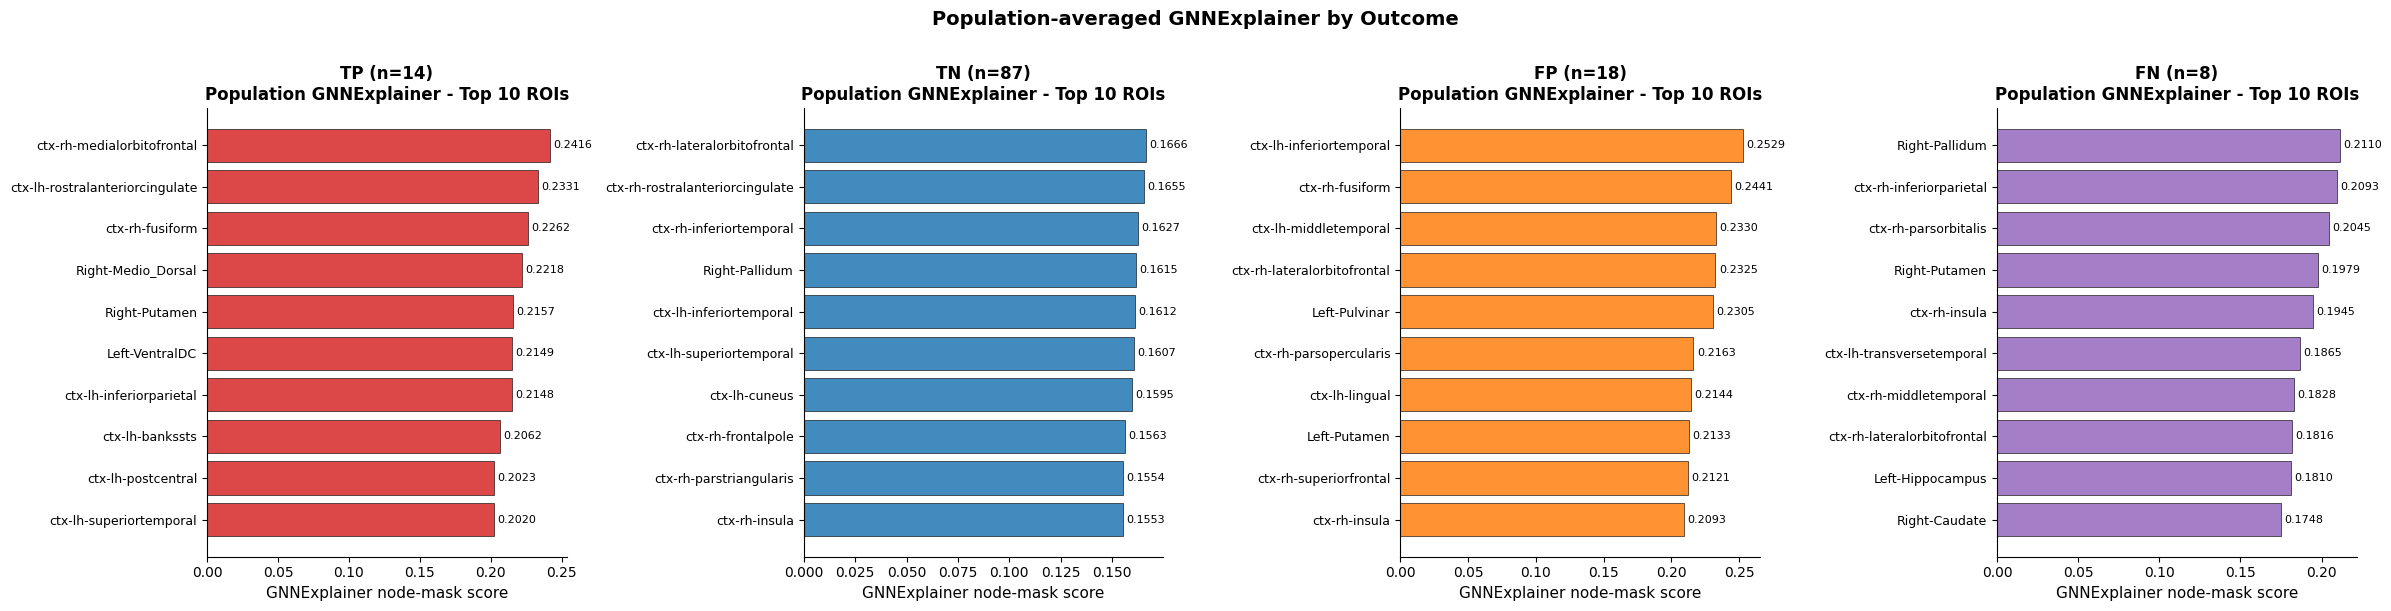

In [10]:
def run_explainer_population(pool, tag, explanation_type='model', target=None):
    nodes, edges, feats = [], [], []
    n_edges_ref = pool[0][0].edge_index.size(1)  # edges differ per subject so we can't stack edges directly
    edge_per_subject = []                          # store per-subject edge scores keyed by (u,v)
    for g, true, pred, _ in pool:
        n_imp, f_imp, e_imp, _ = run_gnnexplainer(g, target=target,
                                                  explanation_type=explanation_type)
        nodes.append(n_imp)
        feats.append(f_imp)
        ei = g.edge_index.cpu().numpy()
        # accumulate edge scores in a dict keyed by undirected node pair
        per_subj = {}
        for k in range(ei.shape[1]):
            u, v = int(ei[0, k]), int(ei[1, k])
            key  = (min(u, v), max(u, v))
            per_subj[key] = max(per_subj.get(key, 0.0), float(e_imp[k]))
        edge_per_subject.append(per_subj)
    mean_node = np.stack(nodes).mean(axis=0)
    mean_feat = np.stack(feats).mean(axis=0)
    # aggregate edges: union of keys, mean across subjects (missing = 0)
    all_keys  = set().union(*edge_per_subject)
    mean_edge = {k: np.mean([d.get(k, 0.0) for d in edge_per_subject]) for k in all_keys}
    print(f'{tag} (n={len(pool)}): population GNNExplainer done.')
    return mean_node, mean_feat, mean_edge


pop_results = {}
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if not pool:
        continue
    m_node, m_feat, m_edge = run_explainer_population(pool, tag, explanation_type='model')
    pop_results[tag] = dict(node=m_node, feat=m_feat, edge=m_edge, n=len(pool))


# plot top-10 nodes per outcome
available_tags = [t for t in ['TP', 'TN', 'FP', 'FN'] if t in pop_results]
fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
if len(available_tags) == 1:
    axes = [axes]
for ax, tag in zip(axes, available_tags):
    n = pop_results[tag]['n']
    _, top_names, top_scores = get_top_nodes(pop_results[tag]['node'], node_labels)
    plot_top_nodes(ax, top_names, top_scores,
                   f'{tag} (n={n})\nPopulation GNNExplainer - Top 10 ROIs', outcome_colors[tag])
plt.suptitle('Population-averaged GNNExplainer by Outcome',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

CN (n=105): population GNNExplainer done.
CN: n=105  |  acc on this class = 87/105 = 0.829
MCI (n=22): population GNNExplainer done.
MCI: n=22  |  acc on this class = 14/22 = 0.636


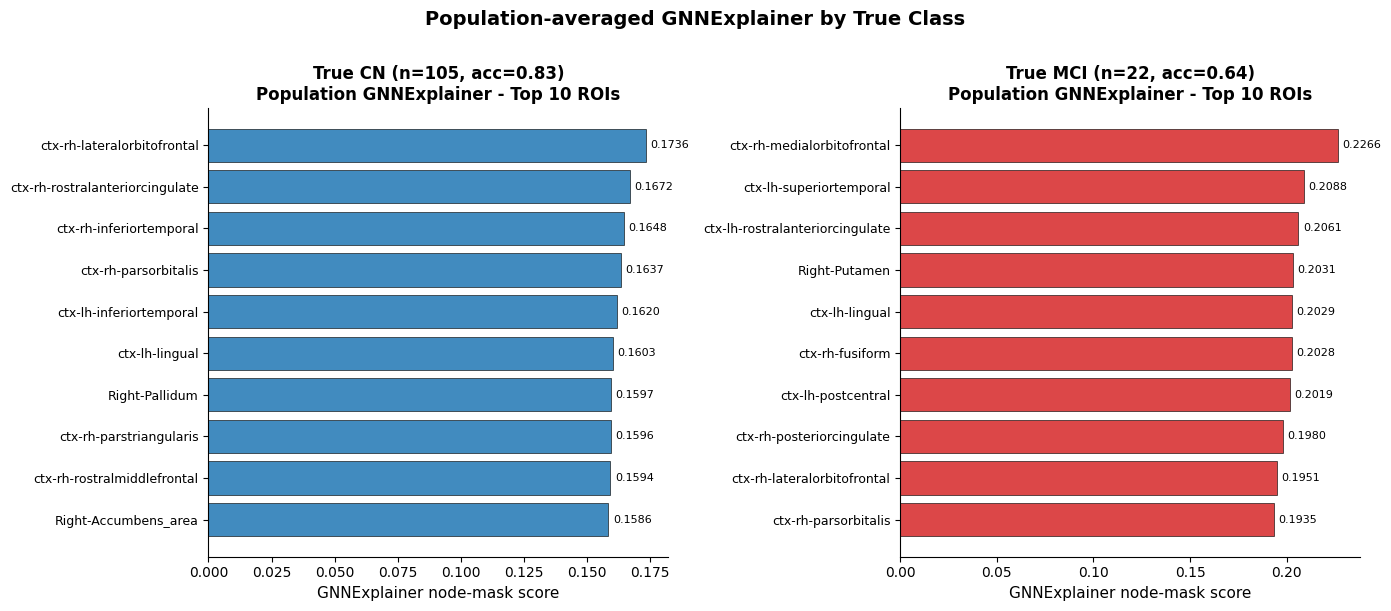

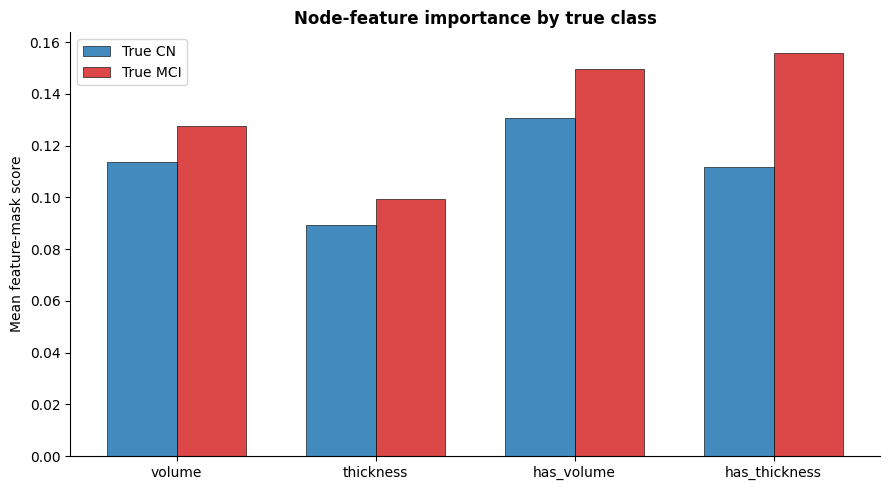

In [11]:
class_pools  = {'CN': cn_pool, 'MCI': mci_pool}
class_target = {'CN': 0, 'MCI': 1}
class_colors = {'CN': '#1f77b4', 'MCI': '#d62728'}

class_pop_results = {}
for cname, pool in class_pools.items():
    m_node, m_feat, m_edge = run_explainer_population(
        pool, cname,
        explanation_type='phenomenon',
        target=class_target[cname],
    )
    correct = sum(1 for _, t, p, _ in pool if t == p)
    class_pop_results[cname] = dict(node=m_node, feat=m_feat, edge=m_edge,
                                    n=len(pool), acc=correct / len(pool))
    print(f'{cname}: n={len(pool)}  |  acc on this class = {correct}/{len(pool)} = {correct/len(pool):.3f}')


# top ROIs per true class
fig, axes = plt.subplots(1, len(class_pop_results), figsize=(7 * len(class_pop_results), 6))
if len(class_pop_results) == 1:
    axes = [axes]
for ax, cname in zip(axes, class_pop_results.keys()):
    info = class_pop_results[cname]
    _, top_names, top_scores = get_top_nodes(info['node'], node_labels)
    plot_top_nodes(ax, top_names, top_scores,
                   f'True {cname} (n={info["n"]}, acc={info["acc"]:.2f})\n'
                   f'Population GNNExplainer - Top 10 ROIs',
                   class_colors[cname])
plt.suptitle('Population-averaged GNNExplainer by True Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# feature-level importance per class
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.35
xs    = np.arange(len(NODE_FEATURE_NAMES))
for i, cname in enumerate(class_pop_results):
    ax.bar(xs + (i - 0.5) * width, class_pop_results[cname]['feat'],
           width=width, label=f'True {cname}', color=class_colors[cname],
           alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(NODE_FEATURE_NAMES)
ax.set_ylabel('Mean feature-mask score')
ax.set_title('Node-feature importance by true class', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

CN (target=MCI) (n=105): population GNNExplainer done.
MCI (target=MCI) (n=22): population GNNExplainer done.


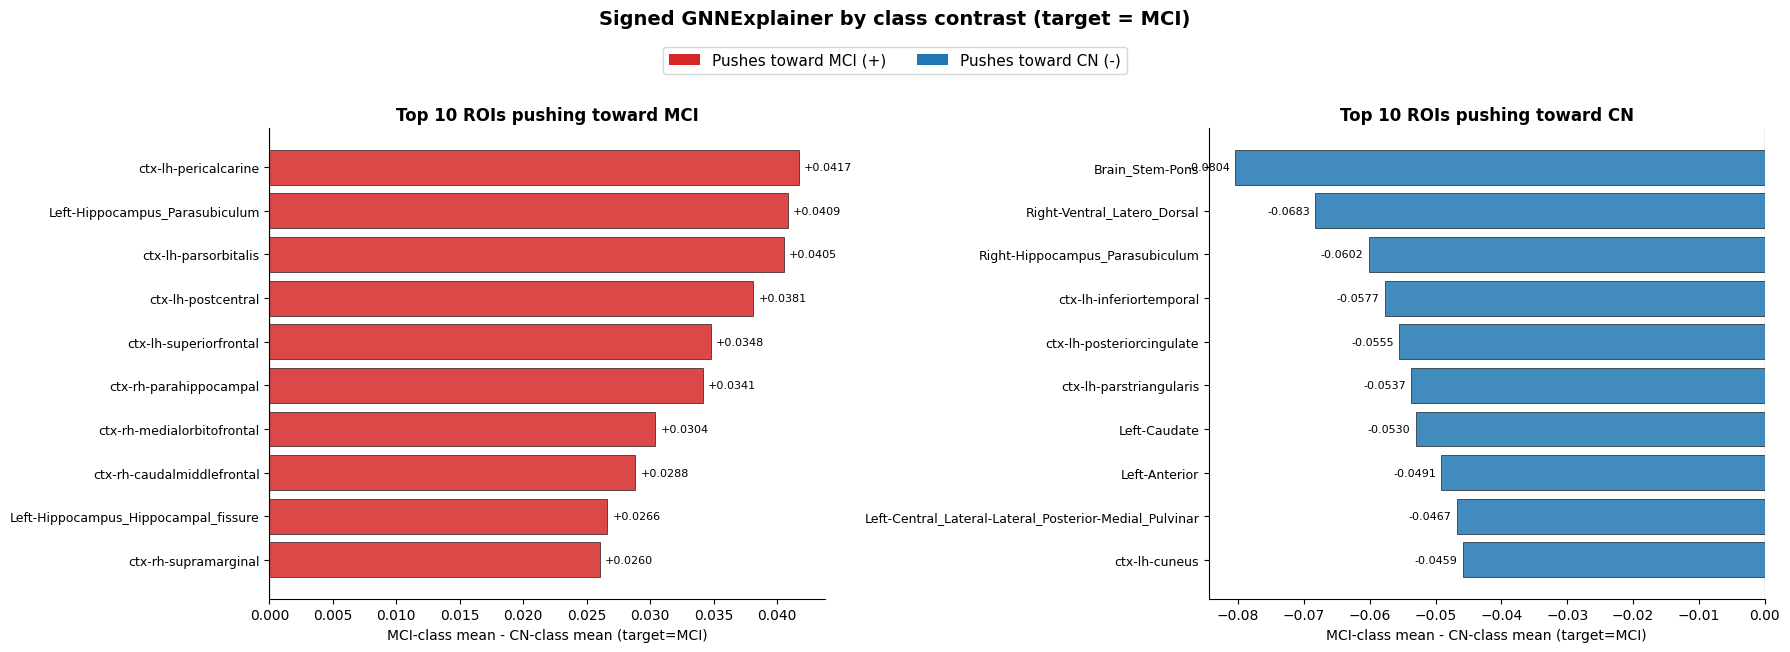


Top ROIs pushing toward MCI:
  ctx-lh-pericalcarine                          | contrast = +0.04171
  Left-Hippocampus_Parasubiculum                | contrast = +0.04085
  ctx-lh-parsorbitalis                          | contrast = +0.04052
  ctx-lh-postcentral                            | contrast = +0.03812
  ctx-lh-superiorfrontal                        | contrast = +0.03479
  ctx-rh-parahippocampal                        | contrast = +0.03413
  ctx-rh-medialorbitofrontal                    | contrast = +0.03039
  ctx-rh-caudalmiddlefrontal                    | contrast = +0.02884
  Left-Hippocampus_Hippocampal_fissure          | contrast = +0.02662
  ctx-rh-supramarginal                          | contrast = +0.02601

Top ROIs pushing toward CN:
  Brain_Stem-Pons                               | contrast = -0.08042
  Right-Ventral_Latero_Dorsal                   | contrast = -0.06827
  Right-Hippocampus_Parasubiculum               | contrast = -0.06017
  ctx-lh-inferiortemporal      

In [12]:
# For both classes, explain with target = MCI so the sign has a consistent meaning.
signed_class_results = {}
for cname, pool in class_pools.items():
    m_node, m_feat, m_edge = run_explainer_population(
        pool, f'{cname} (target=MCI)',
        explanation_type='phenomenon',
        target=1,  # always MCI
    )
    signed_class_results[cname] = dict(node=m_node, feat=m_feat, edge=m_edge, n=len(pool))


# contrast: MCI-mean - CN-mean
node_contrast = signed_class_results['MCI']['node'] - signed_class_results['CN']['node']

# top positive and top negative
top_n   = 10
pos_idx = np.argsort(node_contrast)[::-1][:top_n]
neg_idx = np.argsort(node_contrast)[:top_n]


def plot_signed_bar(ax, idx, contrast, node_labels, title, ascending=True):
    order = np.argsort(contrast[idx])
    if not ascending:
        order = order[::-1]
    idx_sorted = idx[order]
    names  = [node_labels[i] for i in idx_sorted]
    scores = contrast[idx_sorted]
    colors = [class_colors['MCI'] if s >= 0 else class_colors['CN'] for s in scores]
    ax.barh(names, scores, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('MCI-class mean - CN-class mean (target=MCI)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)
    for y, s in enumerate(scores):
        offset = max(np.abs(scores)) * 0.01
        ha = 'left' if s >= 0 else 'right'
        ax.text(s + (offset if s >= 0 else -offset), y,
                f'{s:+.4f}', va='center', ha=ha, fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plot_signed_bar(axes[0], pos_idx, node_contrast, node_labels,
                f'Top {top_n} ROIs pushing toward MCI', ascending=True)
plot_signed_bar(axes[1], neg_idx, node_contrast, node_labels,
                f'Top {top_n} ROIs pushing toward CN', ascending=False)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=class_colors['MCI'], label='Pushes toward MCI (+)'),
    Patch(facecolor=class_colors['CN'],  label='Pushes toward CN (-)'),
]
fig.legend(handles=legend_elems, loc='upper center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 1.03))
plt.suptitle('Signed GNNExplainer by class contrast (target = MCI)',
             fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()


print('\nTop ROIs pushing toward MCI:')
for i in pos_idx:
    print(f'  {node_labels[i]:<45s} | contrast = {node_contrast[i]:+.5f}')
print('\nTop ROIs pushing toward CN:')
for i in neg_idx:
    print(f'  {node_labels[i]:<45s} | contrast = {node_contrast[i]:+.5f}')

In [13]:
# === Εξαγωγή αριθμητικών για την αναφορά ===
# Τρέχει ΜΟΝΟ μετά τα cells 10 και 11 — χρησιμοποιεί τις μεταβλητές
# class_pop_results και signed_class_results που έχουν ήδη υπολογιστεί.

print('='*70)
print('1) ΣΗΜΑΝΤΙΚΟΤΗΤΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ ΚΛΑΣΗ (από cell 10)')
print('='*70)
print(f'{"feature":<18s} {"CN":>10s} {"MCI":>10s} {"MCI-CN":>10s}')
for i, fname in enumerate(NODE_FEATURE_NAMES):
    cn_v  = class_pop_results['CN']['feat'][i]
    mci_v = class_pop_results['MCI']['feat'][i]
    print(f'{fname:<18s} {cn_v:>10.5f} {mci_v:>10.5f} {mci_v-cn_v:>+10.5f}')


print('\n' + '='*70)
print('2) TOP-10 ROIs ΑΝΑ ΚΛΑΣΗ (από cell 10)')
print('='*70)
for cname in ['CN', 'MCI']:
    print(f'\n--- True {cname} (n={class_pop_results[cname]["n"]}) ---')
    arr = class_pop_results[cname]['node']
    top_idx = np.argsort(arr)[::-1][:10]
    for r, i in enumerate(top_idx):
        print(f'  {r+1:>2d}. {node_labels[i]:<45s} | {arr[i]:.6f}')


print('\n' + '='*70)
print('3) TOP-10 ΑΚΜΕΣ ΑΝΑ ΚΛΑΣΗ (από cell 10)')
print('='*70)
for cname in ['CN', 'MCI']:
    print(f'\n--- True {cname} (n={class_pop_results[cname]["n"]}) ---')
    edge_dict = class_pop_results[cname]['edge']   # dict { (u,v): score }
    top = sorted(edge_dict.items(), key=lambda kv: -kv[1])[:10]
    for r, ((u, v), s) in enumerate(top):
        u_name = node_labels.get(int(u), str(u))
        v_name = node_labels.get(int(v), str(v))
        print(f'  {r+1:>2d}. {u_name[:25]:<25s} <-> {v_name[:25]:<25s} | {s:.6f}')


print('\n' + '='*70)
print('4) SIGNED ΑΝΑΛΥΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ (από cell 11, target=MCI)')
print('='*70)
print(f'{"feature":<18s} {"CN-pool":>10s} {"MCI-pool":>10s} {"contrast":>10s}')
for i, fname in enumerate(NODE_FEATURE_NAMES):
    cn_v  = signed_class_results['CN']['feat'][i]
    mci_v = signed_class_results['MCI']['feat'][i]
    print(f'{fname:<18s} {cn_v:>10.5f} {mci_v:>10.5f} {mci_v-cn_v:>+10.5f}')


print('\n' + '='*70)
print('5) SIGNED ΑΝΑΛΥΣΗ ΑΚΜΩΝ (από cell 11, target=MCI)')
print('='*70)
edge_cn  = signed_class_results['CN']['edge']
edge_mci = signed_class_results['MCI']['edge']
all_keys = set(edge_cn) | set(edge_mci)
edge_contrast = {k: edge_mci.get(k, 0.0) - edge_cn.get(k, 0.0) for k in all_keys}

print('\n--- Top 10 ακμές που ωθούν προς MCI ---')
top_pos = sorted(edge_contrast.items(), key=lambda kv: -kv[1])[:10]
for r, ((u, v), c) in enumerate(top_pos):
    u_name = node_labels.get(int(u), str(u))
    v_name = node_labels.get(int(v), str(v))
    print(f'  {r+1:>2d}. {u_name[:25]:<25s} <-> {v_name[:25]:<25s} | {c:+.6f}')

print('\n--- Top 10 ακμές που ωθούν προς CN ---')
top_neg = sorted(edge_contrast.items(), key=lambda kv: kv[1])[:10]
for r, ((u, v), c) in enumerate(top_neg):
    u_name = node_labels.get(int(u), str(u))
    v_name = node_labels.get(int(v), str(v))
    print(f'  {r+1:>2d}. {u_name[:25]:<25s} <-> {v_name[:25]:<25s} | {c:+.6f}')

1) ΣΗΜΑΝΤΙΚΟΤΗΤΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ ΚΛΑΣΗ (από cell 10)
feature                    CN        MCI     MCI-CN
volume                0.11387    0.12769   +0.01382
thickness             0.08954    0.09936   +0.00982
has_volume            0.13062    0.14978   +0.01916
has_thickness         0.11168    0.15603   +0.04435

2) TOP-10 ROIs ΑΝΑ ΚΛΑΣΗ (από cell 10)

--- True CN (n=105) ---
   1. ctx-rh-lateralorbitofrontal                   | 0.173628
   2. ctx-rh-rostralanteriorcingulate               | 0.167235
   3. ctx-rh-inferiortemporal                       | 0.164793
   4. ctx-rh-parsorbitalis                          | 0.163706
   5. ctx-lh-inferiortemporal                       | 0.162011
   6. ctx-lh-lingual                                | 0.160301
   7. Right-Pallidum                                | 0.159738
   8. ctx-rh-parstriangularis                       | 0.159612
   9. ctx-rh-rostralmiddlefrontal                   | 0.159406
  10. Right-Accumbens_area                         